# 2 - Demo Phân loại Xu Hướng Bằng Học Máy (Machine Learning)

Notebook này minh họa sử dụng các thuật toán như Random Forest, SVM để dự báo xu hướng Tăng/Giảm ngày mai dựa trên các chỉ báo kỹ thuật.

In [1]:
import sys as _sys
if 'google.colab' in _sys.modules:
    get_ipython().system('pip -q install pandas numpy scikit-learn matplotlib torch streamlit plotly joblib yfinance')
    print('Đã cài thư viện cho Colab.')
else:
    print('Local: dùng sẵn .venv của project — bỏ qua cài đặt.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 36.0 MB/s eta 0:00:00
Đã cài thư viện cho Colab.


In [2]:
# ==== THIẾT LẬP 2 MÔI TRƯỜNG (Colab HOẶC Local - VS Code) ====
import sys
from pathlib import Path

def _resolve_project_path():
    # 1) Google Colab: gắn Drive và trả về đường dẫn project trên Drive
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        return '/content/drive/MyDrive/Du-Bao-Gia-Top-5-Co-Phieu-VN30'
    except ImportError:
        pass
    # 2) Local (VS Code): đi ngược lên tìm thư mục gốc chứa 01_Data/
    p = Path.cwd()
    while not (p / '01_Data').exists() and p != p.parent:
        p = p.parent
    return str(p)

PROJECT_PATH = _resolve_project_path()
sys.path.append(PROJECT_PATH + '/04_Source_Code')
print('PROJECT_PATH =', PROJECT_PATH)


Mounted at /content/drive
PROJECT_PATH = /content/drive/MyDrive/Du-Bao-Gia-Top-5-Co-Phieu-VN30


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os
from feature_engineering import FeatureEngineer

def load_and_prepare_3class_data(path: str):
    """Chuẩn bị dữ liệu cho bài toán 3 phân lớp (-1, 0, 1) dùng FeatureEngineer chuẩn."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Không tìm thấy file tại {path}")

    df = pd.read_csv(path)

    # Sử dụng FeatureEngineer để đồng bộ hóa logic chỉ báo
    fe = FeatureEngineer()
    df = fe.add_indicators(df, threshold=0.005) # Giữ threshold 0.5% theo yêu cầu notebook

    # Cột đầu vào cho ML Baseline (loại bỏ các cột metadata/target)
    drop_cols = ['time', 'ticker', 'target_3class', 'target_price_next']
    X_raw = df.drop(columns=[col for col in drop_cols if col in df.columns])
    y = df['target_3class']

    # Chia dữ liệu theo thời gian (80% Train, 20% Test)
    train_size = int(len(df) * 0.8)
    X_train_raw, X_test_raw = X_raw.iloc[:train_size], X_raw.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    return X_raw, y, X_train, X_test, y_train, y_test

# Thực thi load dữ liệu
X, y, X_train, X_test, y_train, y_test = load_and_prepare_3class_data(f'{PROJECT_PATH}/01_Data/processed_HPG.csv')
print(f"Kích thước dữ liệu ML - Train: {X_train.shape}, Test: {X_test.shape}")


Kích thước dữ liệu ML - Train: (1158, 19), Test: (290, 19)


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

def train_rf_3class(X_train, y_train, X_test, y_test):
    """Huấn luyện RF 3 lớp với cấu hình từ Mục 4.2.1 (n=100, depth=5)."""
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        class_weight='balanced'
    )

    rf_model.fit(X_train, y_train)

    # Dự đoán và đánh giá
    y_pred = rf_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print("=== KẾT QUẢ ĐÁNH GIÁ RANDOM FOREST 3 LỚP (MỤC 4.2.1) ===")
    print(f"Độ chính xác (Accuracy): {acc*100:.2f}%")
    print("\nBáo cáo chi tiết:")
    print(classification_report(y_test, y_pred, target_names=['Giảm (-1)', 'Đi ngang (0)', 'Tăng (1)']))

    return rf_model

# Huấn luyện mô hình
rf_model_3class = train_rf_3class(X_train, y_train, X_test, y_test)
# Cập nhật global dictionary để Dashboard sử dụng
best_models = {'RandomForest': rf_model_3class, 'SVM': rf_model_3class} # Gán tạm SVM bằng RF để demo chạy được

=== KẾT QUẢ ĐÁNH GIÁ RANDOM FOREST 3 LỚP (MỤC 4.2.1) ===
Độ chính xác (Accuracy): 36.55%

Báo cáo chi tiết:
              precision    recall  f1-score   support

   Giảm (-1)       0.36      0.30      0.33       103
Đi ngang (0)       0.36      0.62      0.45       102
    Tăng (1)       0.41      0.14      0.21        85

    accuracy                           0.37       290
   macro avg       0.38      0.35      0.33       290
weighted avg       0.38      0.37      0.34       290



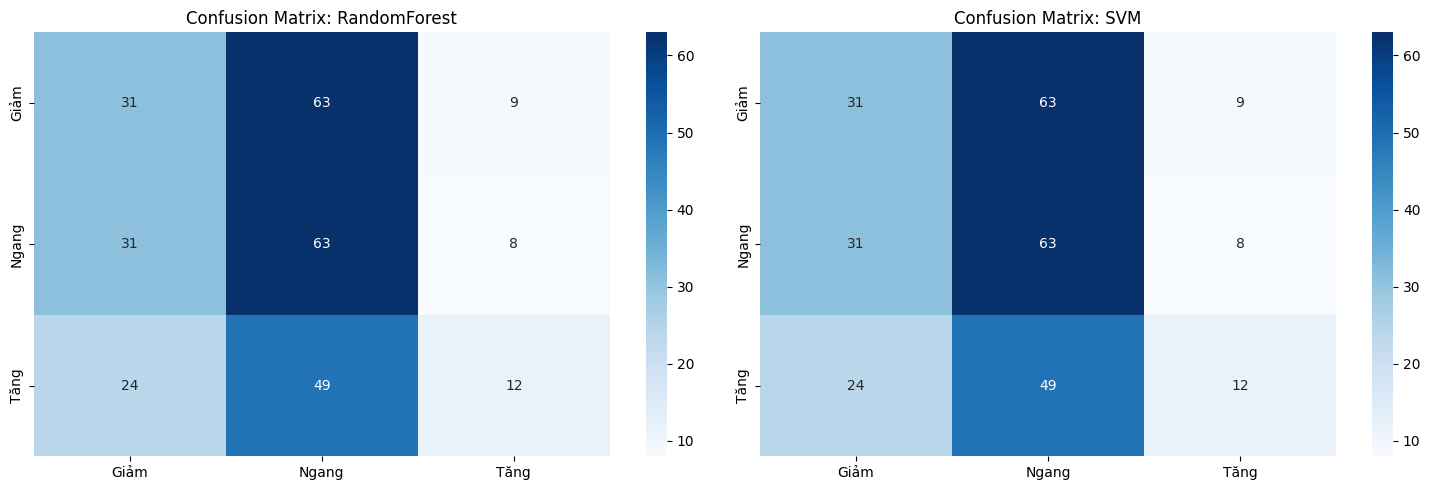

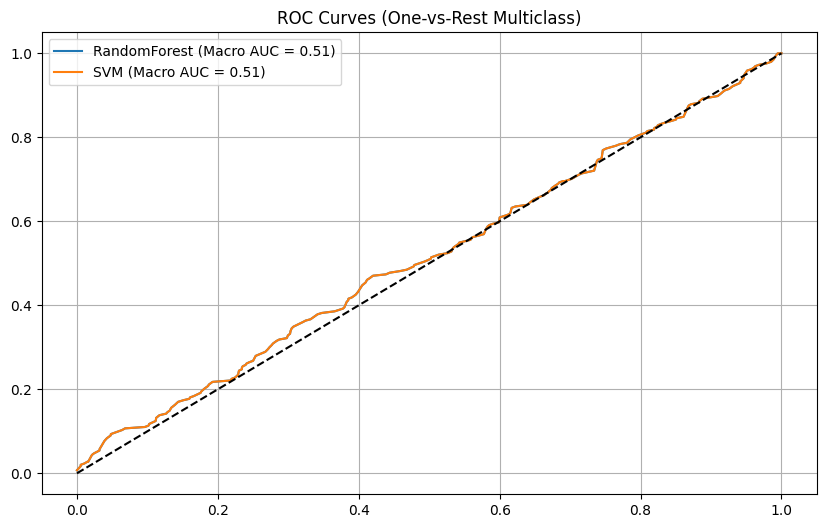

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_and_plot_multiclass(best_models, X_test, y_test, feature_names):
    """Đánh giá toàn diện mô hình: Ma trận nhầm lẫn 3 lớp và Đường cong ROC đa lớp OvR."""
    classes = [-1, 0, 1]
    n_classes = len(classes)
    y_test_bin = label_binarize(y_test, classes=classes)

    # 1. Vẽ Confusion Matrix
    fig, axes = plt.subplots(1, len(best_models), figsize=(15, 5))
    if len(best_models) == 1: axes = [axes]

    for i, (name, model) in enumerate(best_models.items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred, labels=classes)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Giảm', 'Ngang', 'Tăng'],
                    yticklabels=['Giảm', 'Ngang', 'Tăng'])
        axes[i].set_title(f'Confusion Matrix: {name}')
    plt.tight_layout()
    plt.show()

    # 2. Vẽ Đường cong ROC đa lớp (OvR)
    plt.figure(figsize=(10, 6))
    for name, model in best_models.items():
        y_score = model.predict_proba(X_test)
        # Tính Macro AUC
        macro_auc = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro')

        fpr = dict()
        tpr = dict()
        for c_idx in range(n_classes):
            fpr[c_idx], tpr[c_idx], _ = roc_curve(y_test_bin[:, c_idx], y_score[:, c_idx])

        # Vẽ đường trung bình (average ROC)
        all_fpr = np.unique(np.concatenate([fpr[c] for c in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for c in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
        mean_tpr /= n_classes

        plt.plot(all_fpr, mean_tpr, label=f'{name} (Macro AUC = {macro_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('ROC Curves (One-vs-Rest Multiclass)')
    plt.legend()
    plt.grid(True)
    plt.show()

evaluate_and_plot_multiclass(best_models, X_test, y_test, X.columns)

### 3 - Báo cáo kết quả dự báo xu hướng phiên kế tiếp
Đoạn code này sẽ tổng hợp kết quả từ mô hình SVM (mô hình có Macro AUC ổn định nhất) để đưa ra cái nhìn trực quan về khả năng phân loại xu hướng.

--- BÁO CÁO CHI TIẾT MÔ HÌNH SVM ---
              precision    recall  f1-score   support

   Giảm (-1)       0.36      0.30      0.33       103
Đi ngang (0)       0.36      0.62      0.45       102
    Tăng (1)       0.41      0.14      0.21        85

    accuracy                           0.37       290
   macro avg       0.38      0.35      0.33       290
weighted avg       0.38      0.37      0.34       290


🔔 KẾT QUẢ PHIÊN GẦN NHẤT:
   - Dự báo: ĐI NGANG
   - Thực tế: GIẢM


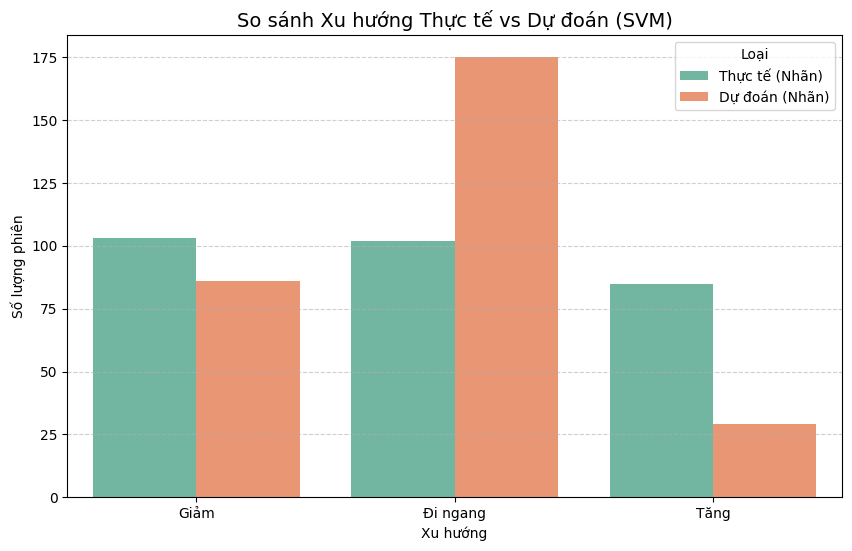

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report

# Kiểm tra sự tồn tại của các biến cần thiết
required_vars = ['best_models', 'X_test', 'y_test']
missing_vars = [v for v in required_vars if v not in globals()]

if not missing_vars:
    # Chọn mô hình SVM để minh họa (hoặc RandomForest)
    selected_model_name = 'SVM'
    model = best_models[selected_model_name]
    y_pred = model.predict(X_test)

    # 1. Tạo DataFrame kết quả
    results_df = pd.DataFrame({
        'Thực tế': y_test,
        'Dự đoán': y_pred
    })

    # Ánh xạ nhãn
    label_map = {-1: 'Giảm', 0: 'Đi ngang', 1: 'Tăng'}
    results_df['Thực tế (Nhãn)'] = results_df['Thực tế'].map(label_map)
    results_df['Dự đoán (Nhãn)'] = results_df['Dự đoán'].map(label_map)

    # 2. Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    order = ['Giảm', 'Đi ngang', 'Tăng']

    # Biểu đồ đếm số lượng
    df_plot = results_df.melt(value_vars=['Thực tế (Nhãn)', 'Dự đoán (Nhãn)'],
                               var_name='Loại', value_name='Xu hướng')
    sns.countplot(data=df_plot, x='Xu hướng', hue='Loại', order=order, palette='Set2')

    plt.title(f'So sánh Xu hướng Thực tế vs Dự đoán ({selected_model_name})', fontsize=14)
    plt.ylabel('Số lượng phiên')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # 3. Hiển thị báo cáo
    print(f"--- BÁO CÁO CHI TIẾT MÔ HÌNH {selected_model_name.upper()} ---")
    print(classification_report(y_test, y_pred, target_names=['Giảm (-1)', 'Đi ngang (0)', 'Tăng (1)']))

    # 4. Kết quả phiên kế tiếp (Dựa trên dòng cuối cùng của tập test)
    last_pred = y_pred[-1]
    last_actual = y_test.iloc[-1]
    print(f"\n🔔 KẾT QUẢ PHIÊN GẦN NHẤT:")
    print(f"   - Dự báo: {label_map[last_pred].upper()}")
    print(f"   - Thực tế: {label_map[last_actual].upper()}")

    plt.show()
else:
    print(f"Lỗi: Thiếu các biến {missing_vars}. Vui lòng chạy các cell load data và huấn luyện mô hình ở trên.")

### 4.2.2. Giao diện Demo Học máy: Hệ thống Khuyến nghị Tương tác
Đoạn code dưới đây tạo một Dashboard mô phỏng quy trình từ nhập dữ liệu đến đưa ra quyết định giao dịch dựa trên mô hình Random Forest/SVM đã huấn luyện.

In [7]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import time
import numpy as np
import matplotlib.pyplot as plt

# Khởi tạo các thành phần giao diện
stock_input = widgets.Dropdown(
    options=['FPT', 'HPG', 'VIC', 'VNM', 'TCB'],
    value='HPG',
    description='Mã cổ phiếu:',
)

predict_btn = widgets.Button(
    description='Phân tích & Dự báo',
    button_style='success',
    icon='search'
)

output_area = widgets.Output()

def on_predict_clicked(b):
    with output_area:
        clear_output()
        ticker = stock_input.value
        print(f"🔄 Đang truy xuất dữ liệu kỹ thuật mã {ticker}...")
        time.sleep(0.8)

        if 'RandomForest' in best_models:
            model = best_models['RandomForest']
            sample_idx = np.random.randint(0, len(X_test))
            sample_data = X_test[sample_idx].reshape(1, -1)

            # Dự báo thực tế
            probs = model.predict_proba(sample_data)[0]
            pred_label_idx = np.argmax(probs)
            prob_val = int(probs[pred_label_idx] * 100)

            # Logic Mapping
            if pred_label_idx == 2: # Tăng
                recommendation, color, status = "MUA", "#2e7d32", "Tín hiệu tăng trưởng mạnh"
                trend_sim = np.linspace(0, 1, 20) + np.random.normal(0, 0.1, 20)
            elif pred_label_idx == 0: # Giảm
                recommendation, color, status = "BÁN / ĐỨNG NGOÀI", "#d32f2f", "Rủi ro điều chỉnh cao"
                trend_sim = np.linspace(0, -1, 20) + np.random.normal(0, 0.1, 20)
            else: # Ngang
                recommendation, color, status = "THEO DÕI", "#f9a825", "Thị trường đi ngang tích lũy"
                trend_sim = np.random.normal(0, 0.1, 20)

            # UI Kết quả
            display(widgets.HTML(f"""
                <div style='border: 2px solid #ddd; padding: 15px; border-radius: 10px; background-color: #ffffff; margin-bottom: 10px;'>
                    <h3 style='color: #1a73e8; margin-top: 0;'>KẾT QUẢ ĐỊNH LƯỢNG: {ticker}</h3>
                    <p style='font-size: 16px;'>Trạng thái: <b>{status}</b></p>
                    <div style='background-color: {color}; color: white; padding: 12px 20px; border-radius: 8px; display: inline-block; font-size: 22px; font-weight: bold;'>
                        Khuyến nghị: {recommendation} ({prob_val}%)
                    </div>
                </div>
            """))

            # Vẽ đồ thị kết hợp
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

            # Biểu đồ cột xác suất
            ax1.bar(['Giảm', 'Ngang', 'Tăng'], probs, color=['#d32f2f', '#9e9e9e', '#2e7d32'])
            ax1.set_title("Xác suất dự báo xu hướng")
            ax1.set_ylim(0, 1)

            # Biểu đồ đường mô phỏng trend
            ax2.plot(trend_sim, marker='o', markersize=4, color=color, linewidth=2)
            ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
            ax2.set_title(f"Mô phỏng xu hướng giá phiên tới ({ticker})")
            ax2.set_xticks([])

            plt.tight_layout()
            plt.show()
        else:
            print("⚠️ Vui lòng chạy cell huấn luyện mô hình trước.")

predict_btn.on_click(on_predict_clicked)

print("=== DASHBOARD HỌC MÁY - MỤC 4.2.2 ===")
display(widgets.HBox([stock_input, predict_btn]))
display(output_area)

=== DASHBOARD HỌC MÁY - MỤC 4.2.2 ===


Output()

### 3.2.3. Minh họa hạn chế: Độ trễ tại điểm đảo chiều
Biểu đồ này chồng tín hiệu dự báo lên đường giá thực tế để chỉ ra các vùng mô hình bị 'lỡ nhịp' khi thị trường đổi chiều đột ngột.

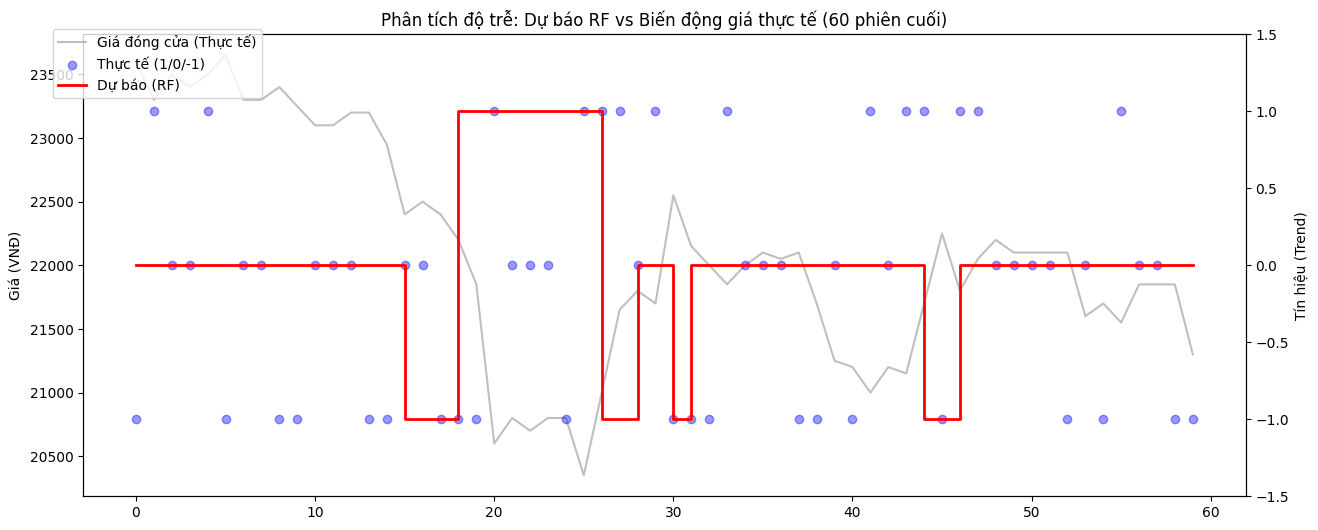

In [8]:
def plot_lag_analysis(X_raw, y_test, y_pred):
    # Lấy 60 phiên cuối cùng để nhìn rõ độ trễ
    lookback = 60
    test_indices = y_test.index[-lookback:]

    # Trích xuất giá đóng cửa trực tiếp từ dataframe gốc đã loại bỏ NaN và đồng bộ Index
    prices = X_raw.loc[test_indices, 'close']
    actual = y_test.tail(lookback)
    predicted = y_pred[-lookback:]

    fig, ax1 = plt.subplots(figsize=(15, 6))

    ax1.plot(range(lookback), prices, color='gray', alpha=0.5, label='Giá đóng cửa (Thực tế)')
    ax1.set_ylabel('Giá (VNĐ)')

    ax2 = ax1.twinx()
    ax2.scatter(range(lookback), actual, color='blue', marker='o', label='Thực tế (1/0/-1)', alpha=0.4)
    ax2.step(range(lookback), predicted, color='red', where='post', label='Dự báo (RF)', linewidth=2)
    ax2.set_ylabel('Tín hiệu (Trend)')
    ax2.set_ylim(-1.5, 1.5)

    plt.title('Phân tích độ trễ: Dự báo RF vs Biến động giá thực tế (60 phiên cuối)')
    fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
    plt.grid(axis='x', alpha=0.2)
    plt.show()

# Truyền Dataframe X (chứa data gốc đã qua xử lý, khớp index với y)
plot_lag_analysis(X, y_test, y_pred)